# ISeeSnow: Real topography — Voellmy — AVAC

This notebook runs one official ISeeSnow case without calibration, writes the required peak-flow-thickness and peak-flow-velocity rasters, and compares them on the supplied grid with participating-model submissions.


## Reproducible environment

The first code cell installs the repository's validation package and Python dependencies into the active kernel. A clean checkout also needs GNU Make and gfortran to compile the selected solver on first use. The pinned official ISeeSnow 1.0 dataset is downloaded automatically on first use.


In [1]:
from pathlib import Path
SEARCH_ROOT = Path.cwd().resolve()
REPOSITORY = next(candidate for candidate in (SEARCH_ROOT, *SEARCH_ROOT.parents) if (candidate / 'validation' / 'pyproject.toml').is_file())
%pip install -q -e {REPOSITORY / 'validation'}


Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
from avac4qgis_validation import validation_case
case = validation_case('ISeeSnow', 'RealTopo')
CORES = max(1, os.cpu_count() or 1)
case.path


PosixPath('/Users/cmgotelli/Desktop/AVAC-QGIS/validation/ISeeSnow/RealTopo')

In [3]:
from avac4qgis_validation.datasets import ensure_iseesnow
benchmark = ensure_iseesnow()
benchmark


PosixPath('/Users/cmgotelli/Desktop/AVAC-QGIS/validation/_data/ISeeSnow')

## Prescribed benchmark configuration

The supplied real-terrain 5 m DEM and release polygon are run with $\mu=0.2$, $\xi=2000$ m/s², and 1.5 m normal release thickness. No peer-model result is used to select an AVAC parameter. The simulation ceiling is 1200 s and the native state is checked for practical arrest.


In [4]:
CASE_NAME = 'RealTopo'
case.run(case.path.parent / 'run_iseesnow_avac.py', '--case', CASE_NAME, '--workers', CORES, '--spatial-order', 2, '--overwrite', cwd=case.path.parent)


Running: /Users/cmgotelli/anaconda3/bin/python /Users/cmgotelli/Desktop/AVAC-QGIS/validation/ISeeSnow/run_iseesnow_avac.py --case RealTopo --workers 8 --spatial-order 2 --overwrite


/Users/cmgotelli/Library/Application Support/AVAC-QGIS/runtime/0.5.12/macos-arm64/python/clawpack-src/geoclaw/src/python/geoclaw/data.py:199: UserWarning: 
  *** WARNING: topofile specs changed in v5.8.0 -- Flag level info now ignored
  warnings.warn(w, UserWarning)
/Users/cmgotelli/Library/Application Support/AVAC-QGIS/runtime/0.5.12/macos-arm64/python/clawpack-src/geoclaw/src/python/geoclaw/data.py:142: UserWarning: 
  *** WARNING: deep_depth parameter ignored as of v5.8.0
  warnings.warn(w, UserWarning)
/Users/cmgotelli/Library/Application Support/AVAC-QGIS/runtime/0.5.12/macos-arm64/python/clawpack-src/geoclaw/src/python/geoclaw/data.py:145: UserWarning: 
  *** WARNING: max_level_deep parameter ignored as of v5.8.0
  warnings.warn(w, UserWarning)
/Users/cmgotelli/Library/Application Support/AVAC-QGIS/runtime/0.5.12/macos-arm64/python/clawpack-src/geoclaw/src/python/geoclaw/data.py:504: UserWarning: 
  *** WARNING: qinit specs changed in v5.8.0 -- Flag level info now ignored
  warni

## Run diagnostics and ISeeSnow submission

The summary records volume, duration, practical stop time, numerical controls, solver hash, and generated standard-format files.


In [5]:
summary = case.json('run_summary.json')
summary


{'case': 'RealTopo',
 'cpu_seconds': 1449.282661,
 'wall_seconds': 328.051917583216,
 'simulation_end_ceiling_seconds': 1200.0,
 'flow_stopped_at_seconds': None,
 'flow_stopped_before_ceiling': False,
 'final_max_speed_mps': 6.894457222380265,
 'speed_limit_mps': 1e+99,
 'spatial_order': 2,
 'limiter': 'vanleer',
 'cfl_target': 0.5,
 'plugin_version': '0.5.14',
 'solver': '/Users/cmgotelli/Desktop/AVAC-QGIS/avac-main/src/AVAC/xgeoclaw',
 'solver_sha256': 'dcb75230e46e78fff05bf3e1d390e946542701b87cead27e2756d70878fc13a4',
 'initial_volume_m3': 248000.69830194116,
 'final_volume_m3': 251455.9863738967,
 'signed_final_volume_m3': 251455.9863738967,
 'relative_volume_change': 0.013932573962952059,
 'native_mass_history': '/Users/cmgotelli/Desktop/AVAC-QGIS/validation/ISeeSnow/RealTopo/native_mass_history.csv',
 'pft': '/Users/cmgotelli/Desktop/AVAC-QGIS/validation/ISeeSnow/RealTopo/Submission/relWog_02RealTopo_null_AVAC4QGIS_pft.asc',
 'pfv': '/Users/cmgotelli/Desktop/AVAC-QGIS/validation/

## Direct peer comparison

Only peer fields with exactly matching dimensions, cell size, and cell-center coordinates are included; no shifting, clipping, padding, or resampling is performed.


Running: /Users/cmgotelli/anaconda3/bin/python /Users/cmgotelli/Desktop/AVAC-QGIS/validation/ISeeSnow/compare_iseesnow.py --case RealTopo


{
  "comparisons": 14,
  "exclusions": 3
}


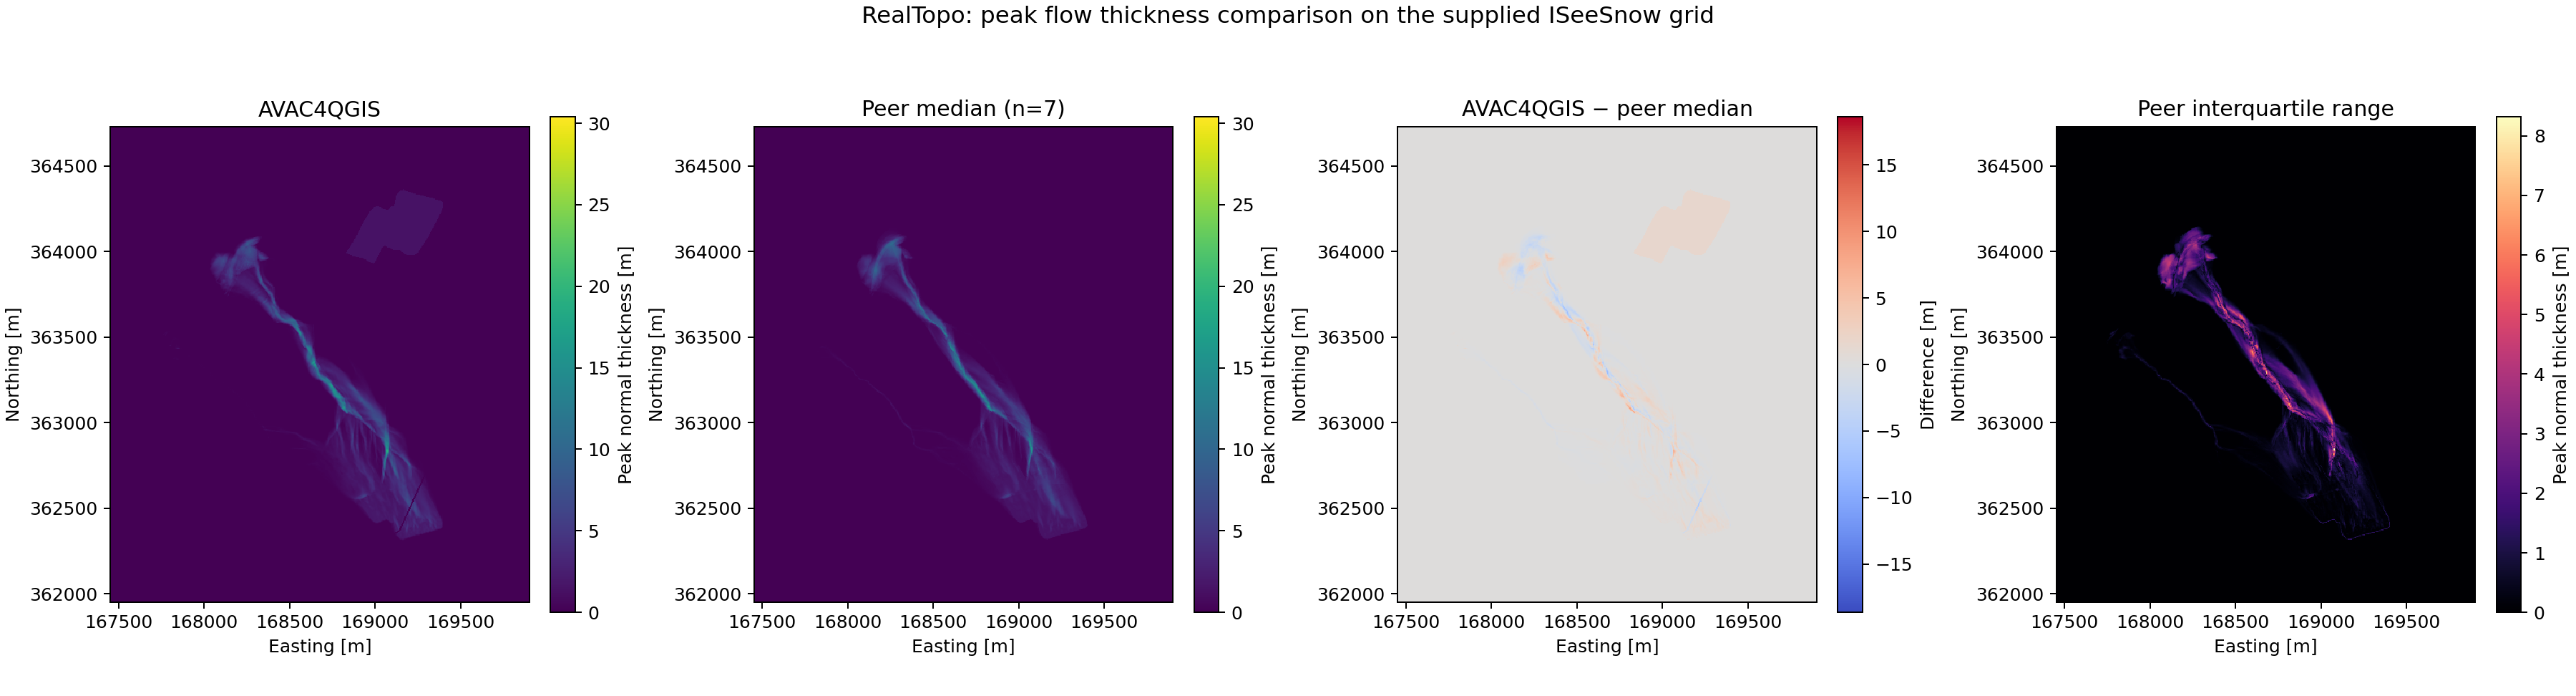

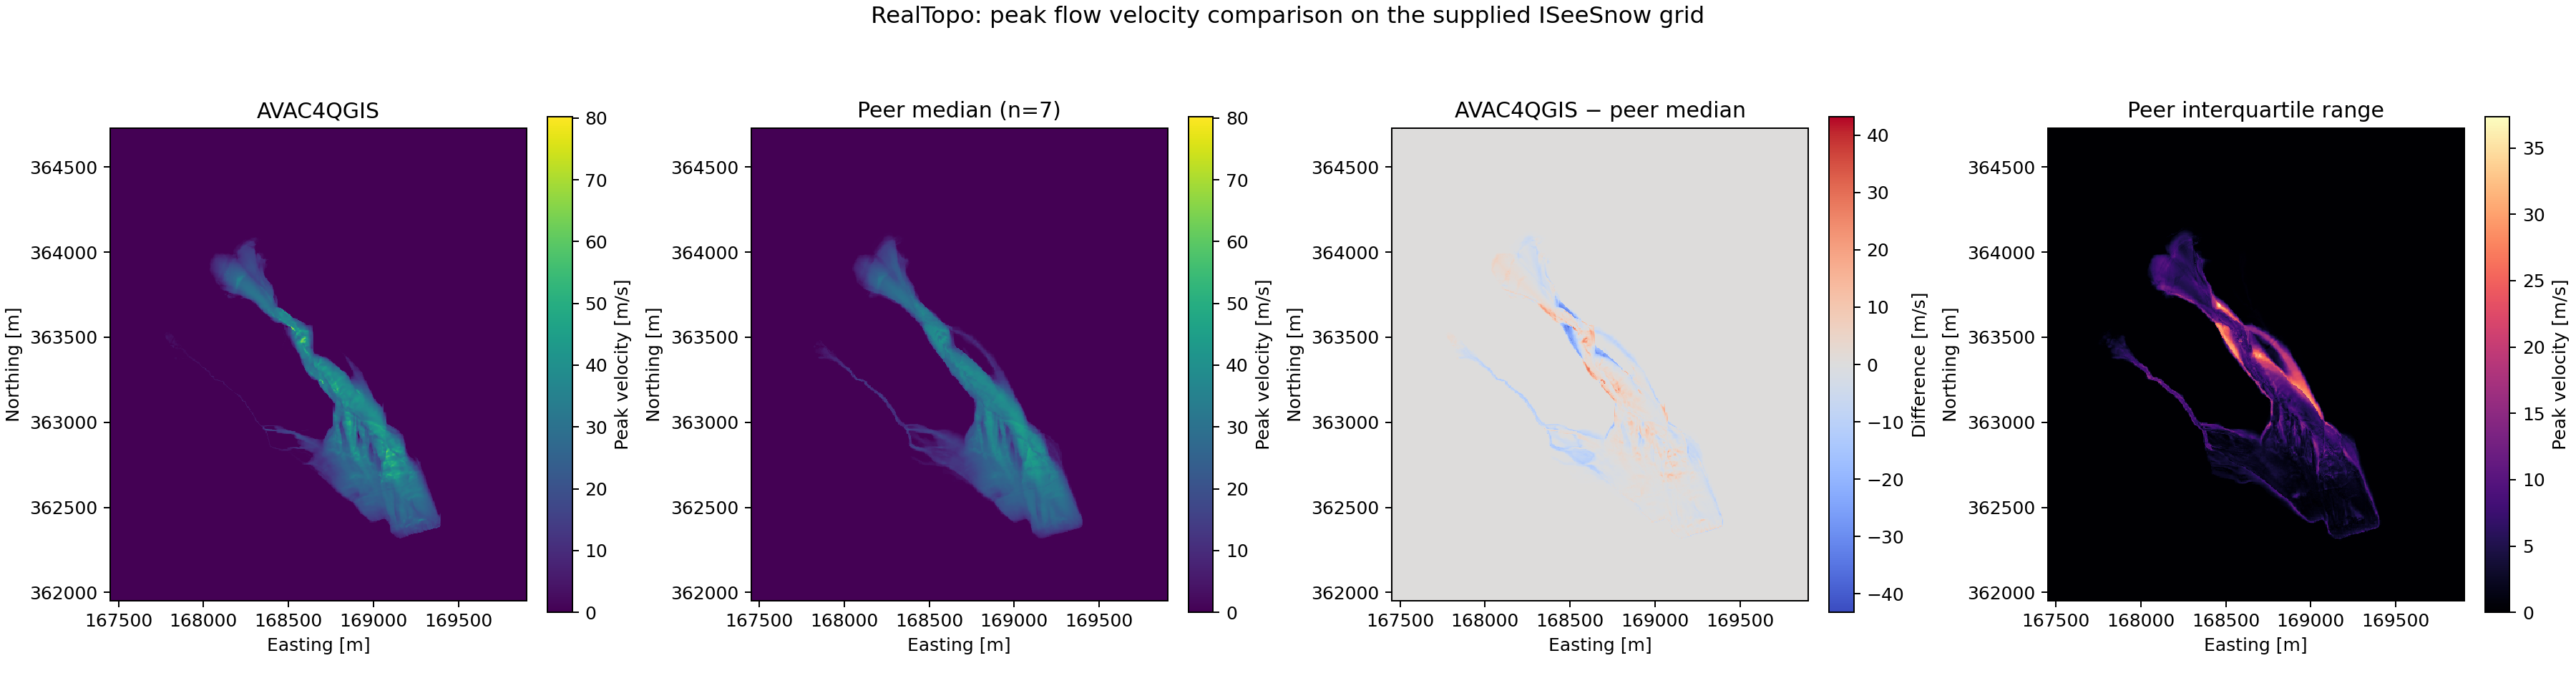

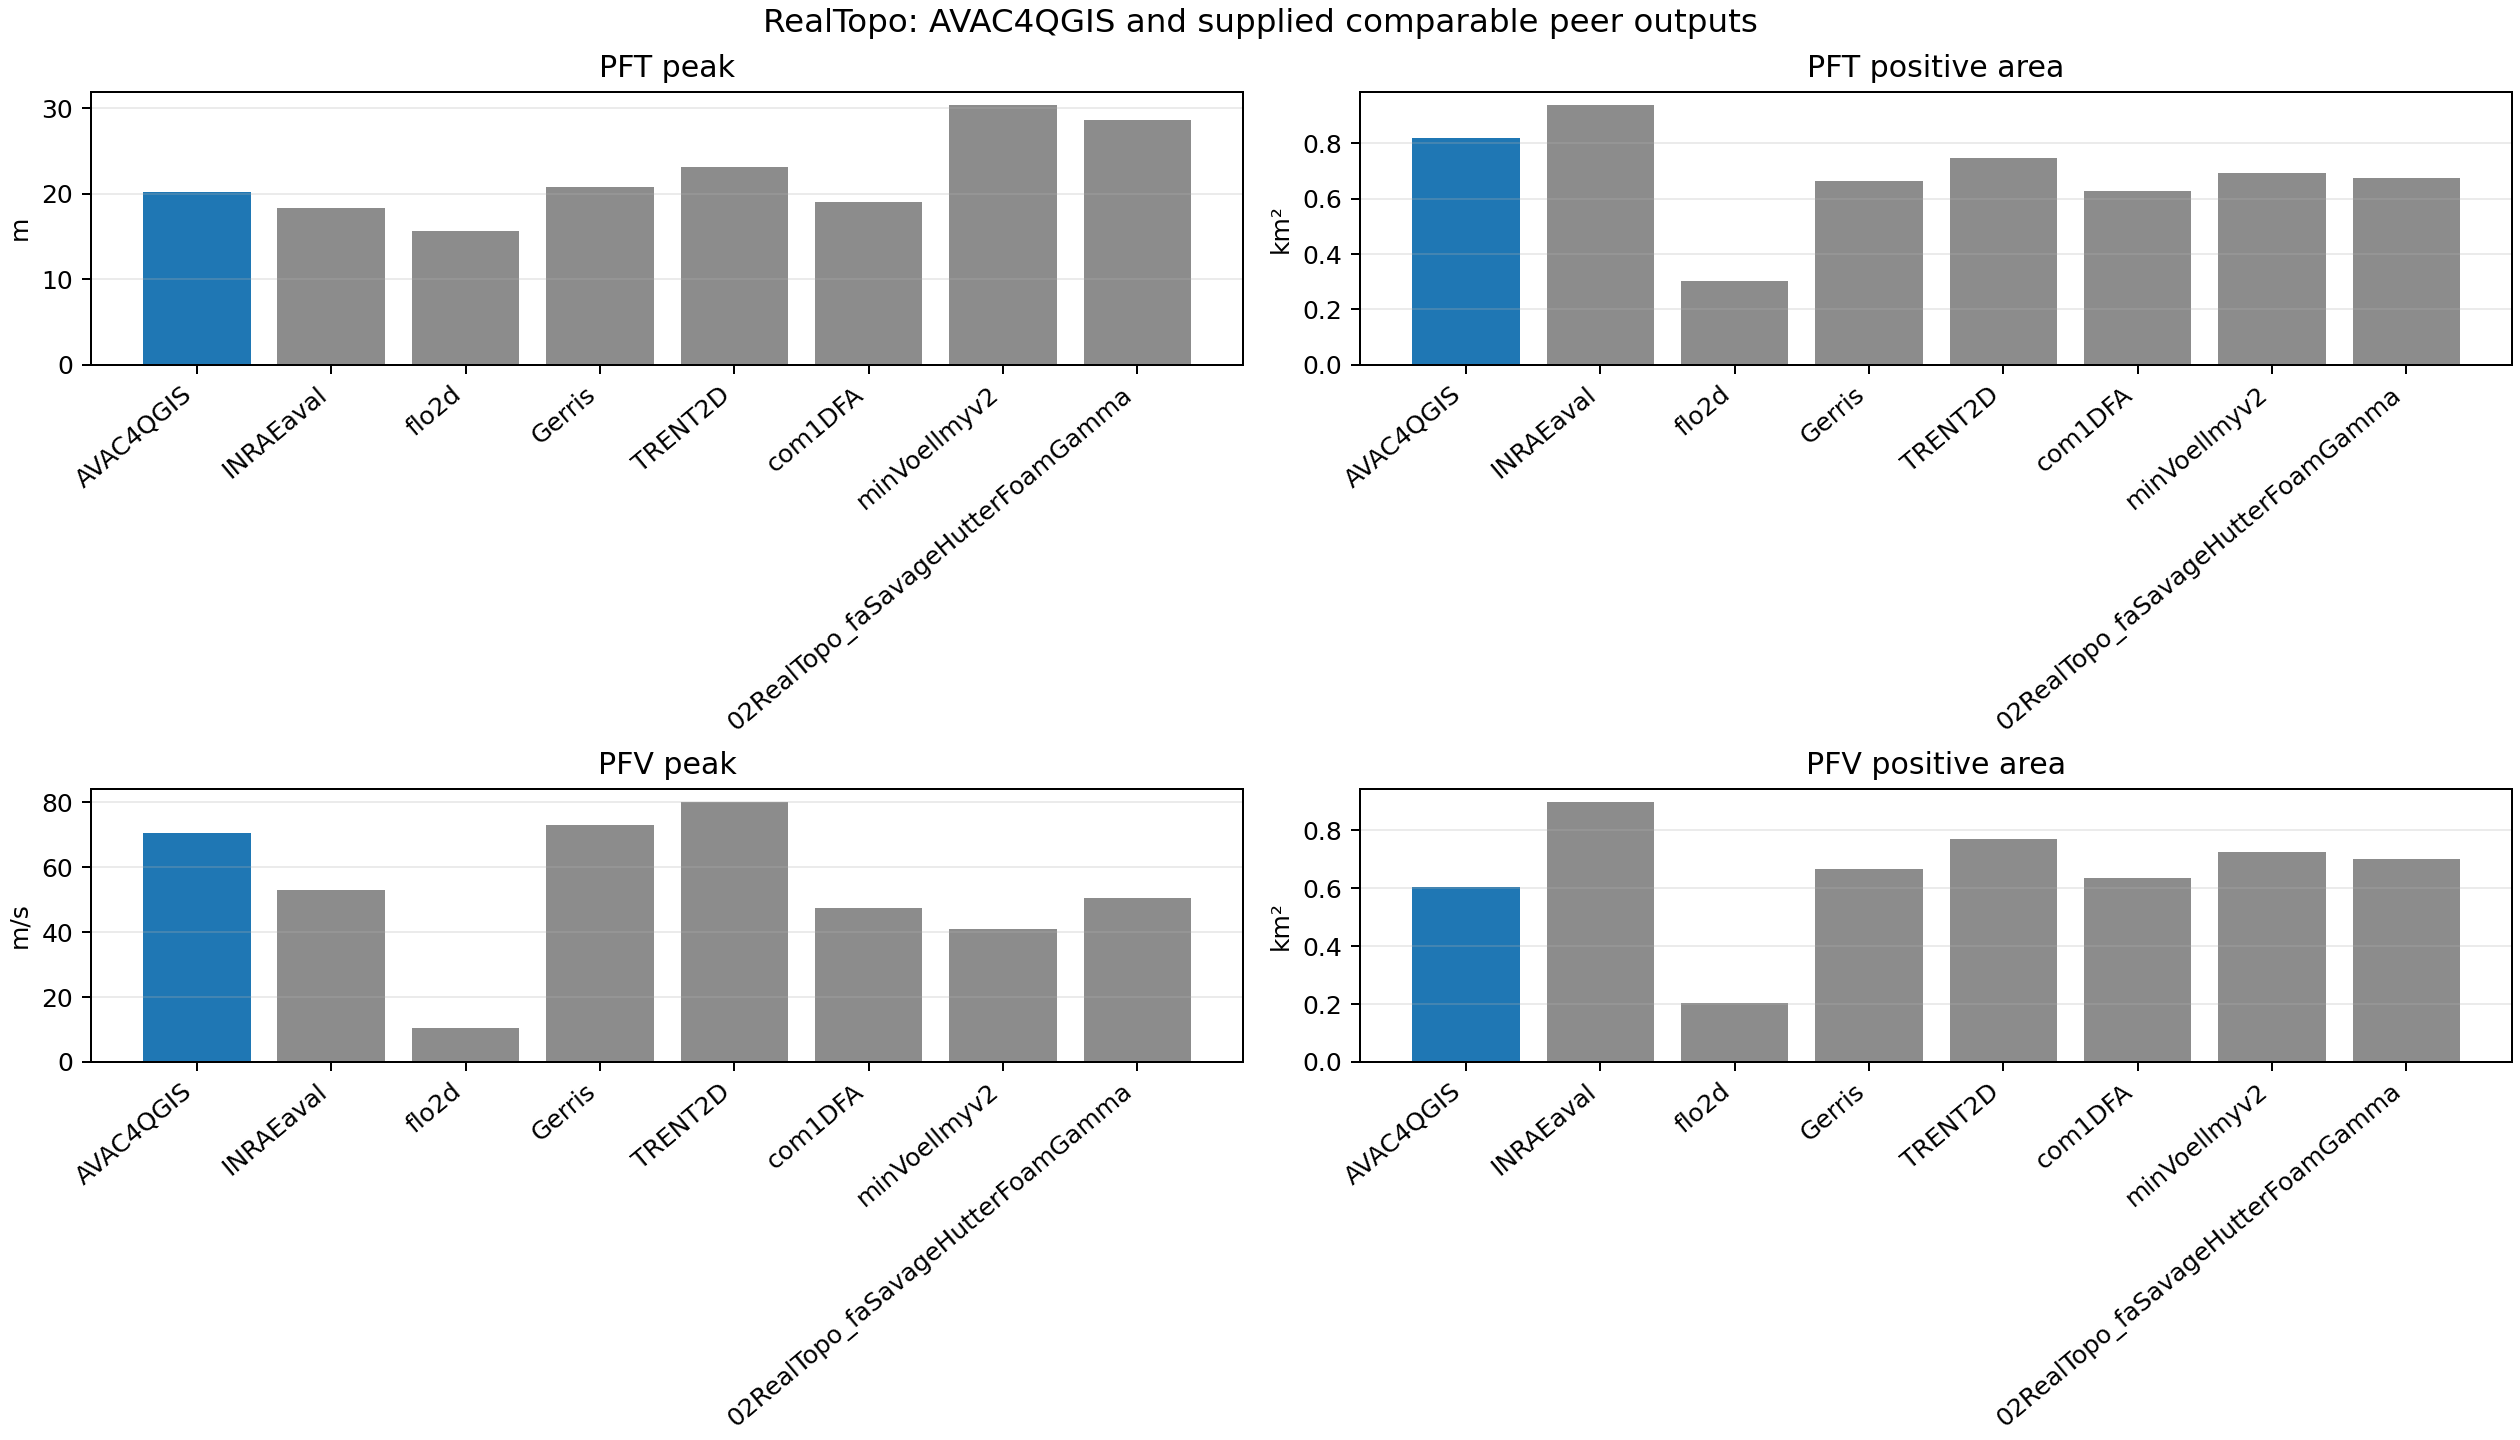

In [6]:
case.run(case.path.parent / 'compare_iseesnow.py', '--case', CASE_NAME, cwd=case.path.parent)
case.show(f'../plots/{CASE_NAME}_pft_peer_comparison.png', f'../plots/{CASE_NAME}_pfv_peer_comparison.png', f'../plots/{CASE_NAME}_scalar_peer_comparison.png')
